In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel("/content/MWLabPart(2).xlsx")
print(df.head())
x=print(df.isnull().sum())

X = df[[
    "age",
    "edu",
    "kidslt6",
    "kidsge6",
    "exper",
    "nwifeinc",
    "city",
    "unem"
]]

y = df["inlf"]

   inlf  hours  kidslt6  kidsge6  age  edu    wage  repwage  hushrs  husage  \
0     1   1610        1        0   32   12   3.354     2.65    2708      34   
1     1   1656        0        2   30   12  1.3889     2.65    2310      30   
2     1   1980        1        3   35   12  4.5455     4.04    3072      40   
3     1    456        0        3   34   12  1.0965     3.25    1920      53   
4     1   1568        1        2   31   14  4.5918     3.60    2000      32   

   husedu  huswage  faminc     mtr  momedu  dadedu  unem  city  exper  \
0      12   4.0288   16310  0.7215      12       7   5.0     0     14   
1       9   8.4416   21800  0.6615       7       7  11.0     1      5   
2      12   3.5807   21040  0.6915      12       7   5.0     0     15   
3      10   3.5417    7300  0.7815       7       7   5.0     0      6   
4      12  10.0000   27300  0.6215      12      14   9.5     1      7   

    nwifeinc  
0  10.910060  
1  19.499980  
2  12.039910  
3   6.799996  
4  20.10006

In [ ]:
df.describe()


,inlf,hours,kidslt6,kidsge6,age,edu,repwage,hushrs,husage,husedu,huswage,faminc,mtr,momedu,dadedu,unem,city,exper,nwifeinc
count,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.00000,753.000000
mean,0.568393,740.576361,0.237716,1.353254,42.537849,12.286853,1.849734,2267.270916,45.120850,12.491368,7.482179,23080.594954,0.678863,9.250996,8.808765,8.623506,0.642762,10.63081,20.128964
std,0.495630,871.314216,0.523959,1.319874,8.072574,2.280246,2.419887,595.566649,8.058793,3.020804,4.230559,12190.202026,0.083496,3.367468,3.572290,3.114934,0.479504,8.06913,11.634797
min,0.000000,0.000000,0.000000,0.000000,30.000000,5.000000,0.000000,175.000000,30.000000,3.000000,0.412100,1500.000000,0.441500,0.000000,0.000000,3.000000,0.000000,0.00000,-0.029057
25%,0.000000,0.000000,0.000000,0.000000,36.000000,12.000000,0.000000,1928.000000,38.000000,11.000000,4.788300,15428.000000,0.621500,7.000000,7.000000,7.500000,0.000000,4.00000,13.025040
50%,1.000000,288.000000,0.000000,1.000000,43.000000,12.000000,0.000000,2164.000000,46.000000,12.000000,6.975800,20880.000000,0.691500,10.000000,7.000000,7.500000,1.000000,9.00000,17.700000
75%,1.000000,1516.000000,0.000000,2.000000,49.000000,13.000000,3.580000,2553.000000,52.000000,15.000000,9.166700,28200.000000,0.721500,12.000000,12.000000,11.000000,1.000000,15.00000,24.466000
max,1.000000,4950.000000,3.000000,8.000000,60.000000,17.000000,9.980000,5010.000000,60.000000,17.000000,40.509000,96000.000000,0.941500,17.000000,17.000000,14.000000,1.000000,45.00000,96.000000


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, Sequential

# 1. Load Excel
df = pd.read_excel("MWLabPart(2).xlsx")

# --- Start of fix for ValueError: could not convert string to float: '.' ---
# Ensure all columns intended for numerical processing are numeric.
# Sometimes Excel files might have '.'' or spaces that pandas reads as objects.
print("Original DataFrame dtypes:")
print(df.dtypes)

for col in df.columns:
    # Attempt to convert to numeric, coercing any errors (like '.') to NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Check for NaNs introduced by the conversion and handle them
if df.isnull().sum().sum() > 0:
    print("\nWarning: Non-numeric values were found and converted to NaN. Handling NaNs...")
    # Filling NaNs with the mean of the column is a common strategy
    # (only for numeric columns, which all should be now after coercion)
    df = df.fillna(df.mean(numeric_only=True))
    print("NaNs filled with column mean.")
else:
    print("\nAll columns are already numeric or successfully converted.")

print("\nDataFrame dtypes after numeric conversion and NaN handling:")
print(df.dtypes)
# --- End of fix for ValueError ---

# 2. Split into X and y
# Based on the problem description, 'inlf' is the Dependent Variable (DV)
y = df['inlf']
X = df.drop('inlf', axis=1) # All other columns are Independent Variables (IVs)

# Convert X to a NumPy array for StandardScaler if it's not already
# (it should be after df.drop, but explicitly call .values for consistency)
X = X.values

# 3. Normalize X (important for stability)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Original DataFrame dtypes:
inlf          int64
hours         int64
kidslt6       int64
kidsge6       int64
age           int64
edu           int64
wage         object
repwage     float64
hushrs        int64
husage        int64
husedu        int64
huswage     float64
faminc        int64
mtr         float64
momedu        int64
dadedu        int64
unem        float64
city          int64
exper         int64
nwifeinc    float64
dtype: object

NaNs filled with column mean.

DataFrame dtypes after numeric conversion and NaN handling:
inlf          int64
hours         int64
kidslt6       int64
kidsge6       int64
age           int64
edu           int64
wage        float64
repwage     float64
hushrs        int64
husage        int64
husedu        int64
huswage     float64
faminc        int64
mtr         float64
momedu        int64
dadedu        int64
unem        float64
city          int64
exper         int64
nwifeinc    float64
dtype: object


In [ ]:
model = Sequential()
model.add(layers.Dense(1, activation='sigmoid', input_shape=(X_train.shape[1],)))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
# Scale the IVs
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
# Build Keras Logistic Regression Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(1, activation="sigmoid", input_shape=(X_train.shape[1],)))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    verbose=1
)


Epoch 1/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6040 - loss: 0.7150
Epoch 2/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6585 - loss: 0.6508
Epoch 3/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6741 - loss: 0.6257
Epoch 4/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7258 - loss: 0.5756
Epoch 5/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7534 - loss: 0.5457
Epoch 6/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7746 - loss: 0.5206
Epoch 7/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7486 - loss: 0.5300
Epoch 8/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7910 - loss: 0.5031
Epoch 9/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8102 - loss: 0.4662
Epoch 10/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7993 - loss: 0.4595
Epoch 11/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8183 - loss: 0.4358
Epoch 12/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy:

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9407 - loss: 0.1889  
Test Accuracy: 0.9470198750495911


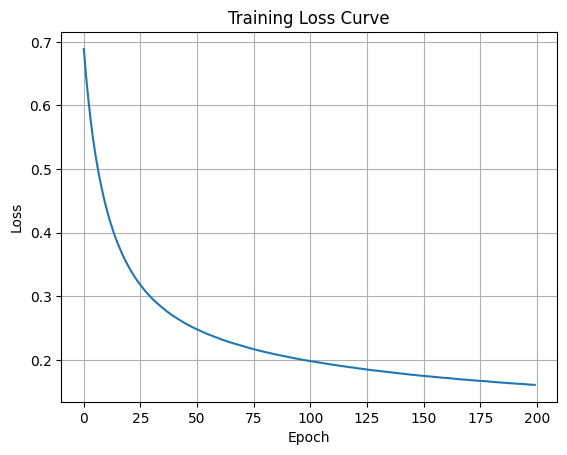

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


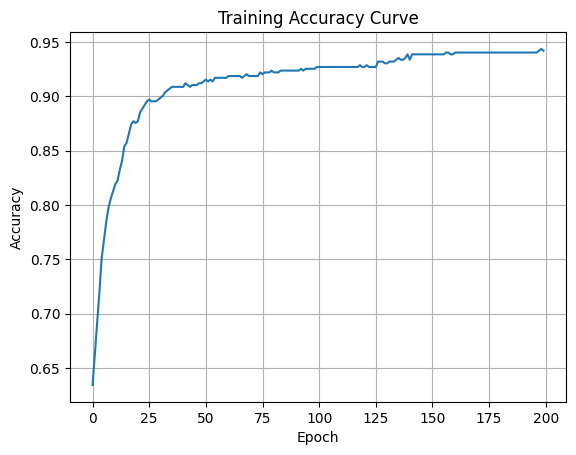

In [ ]:
plt.plot(history.history['accuracy'])
plt.title("Training Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sort values for smooth plotting of the first feature of X_test
x_sorted = np.sort(X_test[:,0])

# Create a full input array for prediction with the correct number of features
num_features = X_train.shape[1]
x_line_full = np.zeros((len(x_sorted), num_features))

# Set the feature being varied (the first one) to the sorted values
x_line_full[:, 0] = x_sorted

# Set all other features to their mean values from the training data
# This allows us to visualize the effect of the first feature while holding others constant
mean_features = np.mean(X_train, axis=0)
for i in range(1, num_features):
    x_line_full[:, i] = mean_features[i]

# Predict sigmoid output using the full input array
y_pred_line = model.predict(x_line_full)

plt.scatter(X_test[:,0], y_test, color='blue', label='Actual')
# Plot the sigmoid curve against the single varied feature
plt.plot(x_sorted, y_pred_line, color='red', label='Sigmoid Fit')

plt.title("Logistic Regression Sigmoid Curve (Effect of First Feature)")
plt.xlabel("First Feature of X_test (Scaled)") # Adjusted label for clarity
plt.ylabel("Probability (sigmoid output)")
plt.legend()
plt.grid(True)
plt.show()

ValueError: X has 19 features, but LogisticRegression is expecting 1 features as input.

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


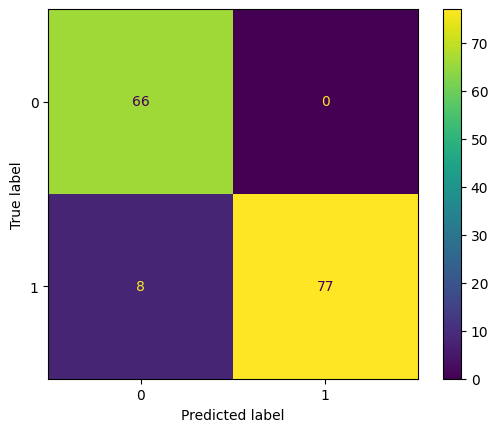

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)
y_pred_class = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
print('VIF values', vif)


VIF values [np.float64(4.342182528908006), np.float64(1.4132391552717332), np.float64(1.3833613119031878), np.float64(5.399345245025089), np.float64(2.0925735287424705), np.float64(1.8901702611606408), np.float64(2.5854959640215704), np.float64(1.7470217836072448), np.float64(4.966320929270477), np.float64(1.928343514762325), np.float64(4.463465792155497), np.float64(56.80002568322208), np.float64(6.507199858120326), np.float64(1.655714777558634), np.float64(1.661865599426856), np.float64(1.0800233257004115), np.float64(1.1922061283970875), np.float64(1.5607539098869532), np.float64(53.471903209082804)]


In [ ]:
df['inlf'].unique()

array([1, 0])

In [ ]:
df.describe()

,inlf,hours,kidslt6,kidsge6,age,edu,wage,repwage,hushrs,husage,husedu,huswage,faminc,mtr,momedu,dadedu,unem,city,exper,nwifeinc
count,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.00000,753.000000
mean,0.568393,740.576361,0.237716,1.353254,42.537849,12.286853,4.177682,1.849734,2267.270916,45.120850,12.491368,7.482179,23080.594954,0.678863,9.250996,8.808765,8.623506,0.642762,10.63081,20.128964
std,0.495630,871.314216,0.523959,1.319874,8.072574,2.280246,2.494423,2.419887,595.566649,8.058793,3.020804,4.230559,12190.202026,0.083496,3.367468,3.572290,3.114934,0.479504,8.06913,11.634797
min,0.000000,0.000000,0.000000,0.000000,30.000000,5.000000,0.128200,0.000000,175.000000,30.000000,3.000000,0.412100,1500.000000,0.441500,0.000000,0.000000,3.000000,0.000000,0.00000,-0.029057
25%,0.000000,0.000000,0.000000,0.000000,36.000000,12.000000,3.166600,0.000000,1928.000000,38.000000,11.000000,4.788300,15428.000000,0.621500,7.000000,7.000000,7.500000,0.000000,4.00000,13.025040
50%,1.000000,288.000000,0.000000,1.000000,43.000000,12.000000,4.177682,0.000000,2164.000000,46.000000,12.000000,6.975800,20880.000000,0.691500,10.000000,7.000000,7.500000,1.000000,9.00000,17.700000
75%,1.000000,1516.000000,0.000000,2.000000,49.000000,13.000000,4.177682,3.580000,2553.000000,52.000000,15.000000,9.166700,28200.000000,0.721500,12.000000,12.000000,11.000000,1.000000,15.00000,24.466000
max,1.000000,4950.000000,3.000000,8.000000,60.000000,17.000000,25.000000,9.980000,5010.000000,60.000000,17.000000,40.509000,96000.000000,0.941500,17.000000,17.000000,14.000000,1.000000,45.00000,96.000000


In [ ]:
# “IVs should be independent of each other (little or no multicollinearity)”


# This is required before hypothesis testing because:

# Interaction terms inflate collinearity

# Quadratic terms inflate collinearity

# # Highly correlated IVs distort coefficients and p-values

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X_vif = sm.add_constant(df[['age','edu','kidslt6','kidsge6','exper','nwifeinc','city','unem']])
vifs = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

In [ ]:
vifs

[np.float64(94.9377135126352),
 np.float64(1.6110668393197969),
 np.float64(1.17741552816444),
 np.float64(1.2610562522736826),
 np.float64(1.2537816570433467),
 np.float64(1.2580603734171072),
 np.float64(1.2138419247886993),
 np.float64(1.1104628280962927),
 np.float64(1.0461040982630616)]

<Axes: ylabel='nwifeinc'>

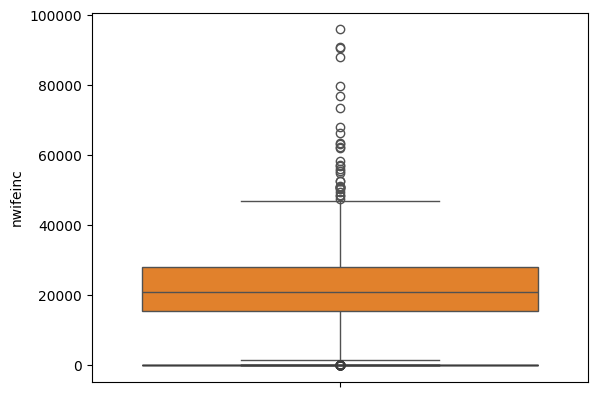

In [ ]:
sns.boxplot(df['nwifeinc'])
sns.boxplot(df['faminc'])
sns.boxplot(df['huswage'])


In [ ]:
# Re-create mean-centered age and experience, and their squared terms
df['age_c'] = df['age'] - df['age'].mean()
df['exper_c'] = df['exper'] - df['exper'].mean()
df['age2'] = df['age_c'] ** 2
df['exper2'] = df['exper_c'] ** 2

model_df = df[[
    'inlf','age_c','age2',
    'exper_c','exper2',
    'edu','kidslt6','kidsge6',
    'nwifeinc','city','unem'
]].dropna()

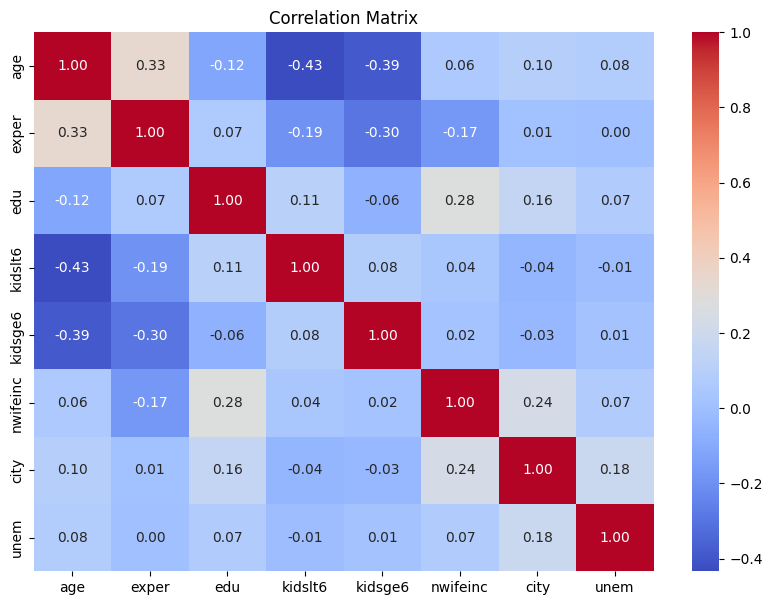

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_vars = [
    "age", "exper", "edu",
    "kidslt6", "kidsge6",
    "nwifeinc",
    "city", "unem"
]

corr = df[corr_vars].corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# PREPROCESSING
# ✔ Handle missing values
# ✔ Outlier detection
# ✔ Correlation matrix
# ✔ VIF
# ✔ Drop huswage (corr > 0.75)

# MODEL DEVELOPMENT
# ✔ Base logistic regression
# ✔ Quadratic hypotheses: age², exper², nwifeinc²
# ✔ Interaction effects: educ×exper, kids interactions, income interactions
# ✔ Compare AIC/deviance and select best model

# HYPOTHESIS TESTING
# ✔ For each coefficient:
# H₀: β = 0
# Use p-values + 95% CI
# ✔ Interpret odds ratios

# DIAGNOSTICS
# ✔ Confusion matrix
# ✔ Accuracy
# ✔ AIC/deviance differences
# ✔ Classification performance

In [ ]:
# TESTS TO PERFORM
# A. CLEANING

# Missing values test

# Numeric conversion test

# Outlier check

# B. MULTICOLLINEARITY

# Correlation matrix

# VIF values

# Decision to drop huswage

# C. FUNCTIONAL FORM CHECKS (NONLINEARITY)

# Add and test quadratic terms (via deviance drop ≥ 2)

# D. INTERACTION EFFECT TESTS

# Try interactions and keep only significant ones

# E. LINEARITY IN LOGIT

# Scatterplots of IV vs logit(p)

# Identify nonlinear patterns

# F. TRAIN/TEST SPLIT VALIDATION

# Ensure generalization

# Compare training vs test accuracy


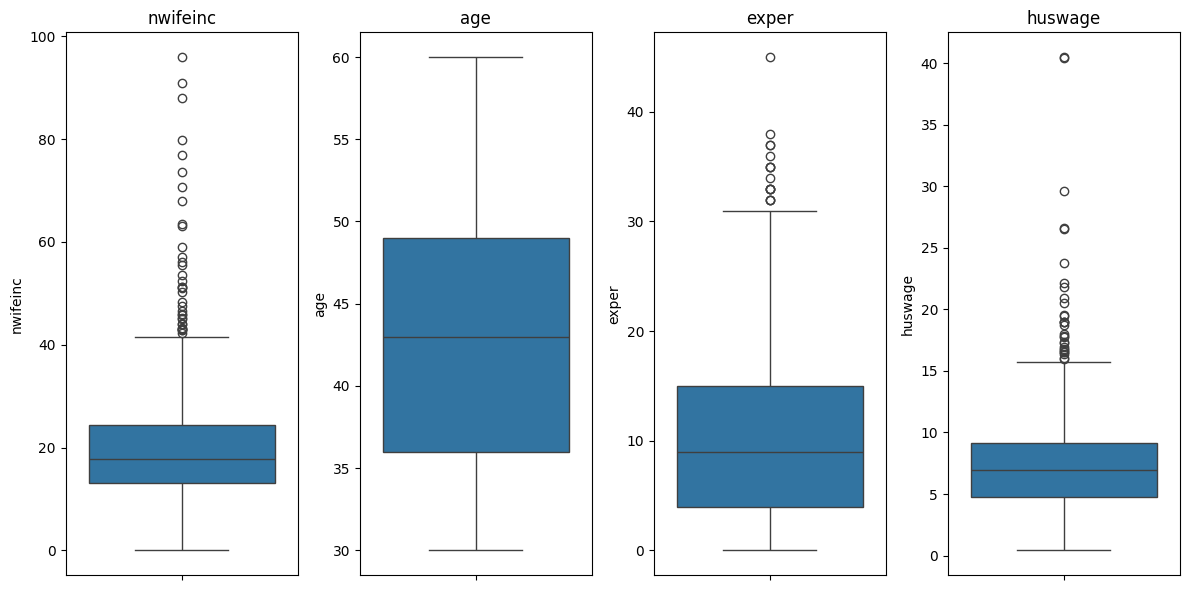

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols_to_check = ["nwifeinc", "age", "exper", "huswage"]

plt.figure(figsize=(12,6))
for i, col in enumerate(cols_to_check,1):
    plt.subplot(1,4,i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()


In [ ]:
print(df.info())

NameError: name 'df' is not defined

In [ ]:
df.decribe()

NameError: name 'df' is not defined

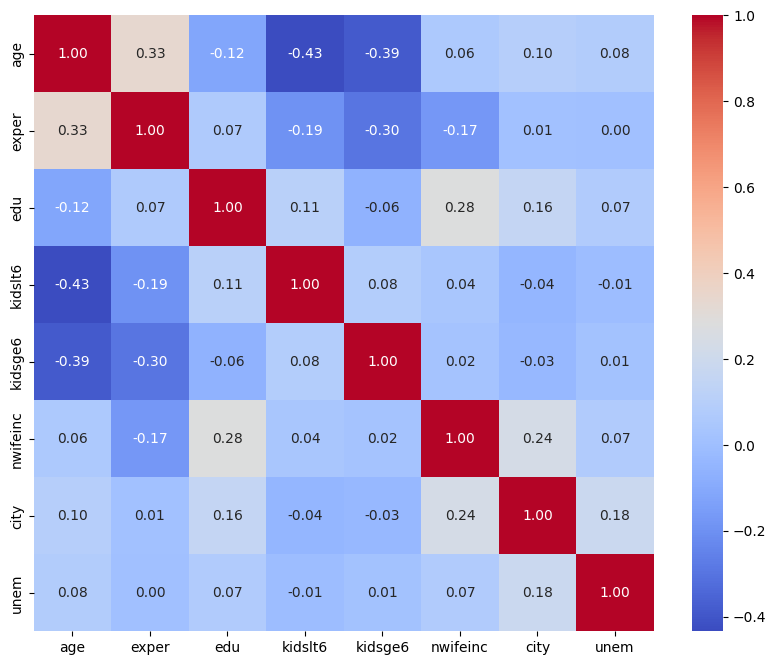

In [ ]:
corr_vars = [
    "age","exper","edu","kidslt6","kidsge6",
    "nwifeinc","city","unem"
]

corr = df[corr_vars].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [ ]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[["age","exper","edu","kidslt6","kidsge6","nwifeinc","city","unem"]]
X_const = sm.add_constant(X)

vif = pd.DataFrame()
vif["variable"] = X_const.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i)
              for i in range(X_const.shape[1])]
print(vif)


   variable        VIF
0     const  94.937714
1       age   1.611067
2     exper   1.258060
3       edu   1.177416
4   kidslt6   1.261056
5   kidsge6   1.253782
6  nwifeinc   1.213842
7      city   1.110463
8      unem   1.046104


In [ ]:
#A woman’s decision to participate in the labor force is shaped by her human capital (education & experience), family responsibilities (children), household financial situation (non-wife income), and location-based opportunities (city). These effects interact with each other and may be nonlinear.

In [ ]:
  # # H1: Education increases the probability of being in the labor force.
  # Higher education increases potential wages → increases the opportunity cost of staying at home → stronger labor force attachment.

In [ ]:
# H2: Experience increases labor force participation, but with diminishing returns.

In [ ]:
# Having young children (<6) decreases labor force participation.

In [ ]:
# Older children (6+) also reduce participation, but less strongly.

In [ ]:
# H5: Higher non-wife income (nwifeinc) reduces participation.

In [ ]:
# H6 (nonlinear income effect):

# # At low incomes, increases discourage participation strongly, but the effect plateaus at higher incomes.

In [ ]:
# H7: Living in a city increases the probability of labor force participation.

In [ ]:
# H8:Local unemployment (unem) decreases participation.

In [ ]:
# H9: Education reduces the negative effect of young children on LFP.


In [ ]:
# H10: The negative effect of non-wife income is weaker in cities.

In [ ]:
# H11: Experience increases participation more strongly when kids are older.

In [ ]:
# Human capital story → H1, H2

# Family burden story → H3, H4

# Household incentives story → H5, H6

# Opportunity structure story → H7, H8

# # Interaction narrative (“how these factors combine”) → H9–H11a

In [ ]:
df.describe()

,inlf,hours,kidslt6,kidsge6,age,edu,wage,repwage,hushrs,husage,husedu,huswage,faminc,mtr,momedu,dadedu,unem,city,exper,nwifeinc
count,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.00000,753.000000
mean,0.568393,740.576361,0.237716,1.353254,42.537849,12.286853,4.177682,1.849734,2267.270916,45.120850,12.491368,7.482179,23080.594954,0.678863,9.250996,8.808765,8.623506,0.642762,10.63081,20.128964
std,0.495630,871.314216,0.523959,1.319874,8.072574,2.280246,2.494423,2.419887,595.566649,8.058793,3.020804,4.230559,12190.202026,0.083496,3.367468,3.572290,3.114934,0.479504,8.06913,11.634797
min,0.000000,0.000000,0.000000,0.000000,30.000000,5.000000,0.128200,0.000000,175.000000,30.000000,3.000000,0.412100,1500.000000,0.441500,0.000000,0.000000,3.000000,0.000000,0.00000,-0.029057
25%,0.000000,0.000000,0.000000,0.000000,36.000000,12.000000,3.166600,0.000000,1928.000000,38.000000,11.000000,4.788300,15428.000000,0.621500,7.000000,7.000000,7.500000,0.000000,4.00000,13.025040
50%,1.000000,288.000000,0.000000,1.000000,43.000000,12.000000,4.177682,0.000000,2164.000000,46.000000,12.000000,6.975800,20880.000000,0.691500,10.000000,7.000000,7.500000,1.000000,9.00000,17.700000
75%,1.000000,1516.000000,0.000000,2.000000,49.000000,13.000000,4.177682,3.580000,2553.000000,52.000000,15.000000,9.166700,28200.000000,0.721500,12.000000,12.000000,11.000000,1.000000,15.00000,24.466000
max,1.000000,4950.000000,3.000000,8.000000,60.000000,17.000000,25.000000,9.980000,5010.000000,60.000000,17.000000,40.509000,96000.000000,0.941500,17.000000,17.000000,14.000000,1.000000,45.00000,96.000000


In [ ]:
# Centering age and experience
df['age_c'] = df['age'] - df['age'].mean()
df['exper_c'] = df['exper'] - df['exper'].mean()

# Optional (you will need these later for quadratic hypotheses)
df['age2'] = df['age_c'] ** 2
df['exper2'] = df['exper_c'] ** 2

print(df[['age','age_c','exper','exper_c']].head())
print(df[['age_c','exper_c']].mean())


   age      age_c  exper  exper_c
0   32 -10.537849     14  3.36919
1   30 -12.537849      5 -5.63081
2   35  -7.537849     15  4.36919
3   34  -8.537849      6 -4.63081
4   31 -11.537849      7 -3.63081
age_c      3.132805e-15
exper_c   -9.058712e-16
dtype: float64


In [ ]:
# age_c

# Subtracts the mean age from every woman’s age → centers around 0.

# exper_c

# Subtracts the mean experience from every woman's experience.

# age2 and exper2

# Create the squared terms using the centered values
# → avoids multicollinearity.

In [ ]:
import statsmodels.api as sm

y = df["inlf"]

X_main = df[[
    "age_c", "exper_c", "edu",
    "kidslt6", "kidsge6",
    "nwifeinc", "city", "unem"
]]

X_main = sm.add_constant(X_main)

logit_main = sm.Logit(y, X_main).fit()
print(logit_main.summary())


Optimization terminated successfully.
         Current function value: 0.539001
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                   inlf   No. Observations:                  753
Model:                          Logit   Df Residuals:                      744
Method:                           MLE   Df Model:                            8
Date:                Mon, 08 Dec 2025   Pseudo R-squ.:                  0.2117
Time:                        09:33:42   Log-Likelihood:                -405.87
converged:                       True   LL-Null:                       -514.87
Covariance Type:            nonrobust   LLR p-value:                 1.013e-42
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.6357      0.550     -2.974      0.003      -2.713      -0.558
age_c         -0.0904      0.

In [ ]:
import numpy as np
odds_ratios_main = np.exp(logit_main.params)
print(odds_ratios_main)


const       0.194819
age_c       0.913573
exper_c     1.127407
edu         1.257413
kidslt6     0.237601
kidsge6     1.063418
nwifeinc    0.979743
city        1.038659
unem        0.979601
dtype: float64


In [ ]:
# . Education (edu)

# coef = +0.2291, p < 0.001, OR = 1.2574

# Education has a positive and statistically significant effect on labor force participation.
# The odds ratio of 1.2574 indicates that:

# Each additional year of schooling increases the odds of being in the labor force by approximately 25.7%.

# This supports the human capital hypothesis that education enhances skills, employability, and opportunity cost of staying at home.

# |

In [ ]:
# xperience (exper_c)

# coef = +0.1199, p < 0.001, OR = 1.1274

# Experience has a strong, positive, statistically significant effect.
# With an odds ratio of 1.1274:

# Each extra year of labor market experience increases the odds of participation by about 12.7%.

# This aligns with theory: women with more experience have better job prospects and higher expected wages.

In [ ]:
# Young children (kidslt6)

# coef = –1.4372, p < 0.001, OR = 0.2376

# This is the largest effect in the model and is highly significant.
# The odds ratio of 0.2376 implies:

# Having at least one child under 6 reduces the odds of being in the labor force by about 76.2%.

# This reflects the heavy childcare burden for younger children, making outside employment more difficult.

In [ ]:
# Older children (kidsge6)

# coef = +0.0615, p = 0.404, OR = 1.0634

# Although the sign is positive, the effect is not statistically significant.

# Having children aged 6–18 does not have a meaningful impact on a woman’s likelihood of working.

# Unlike young children, older children impose less time-intensive care, and empirically their effect here is negligible.

In [ ]:
# Non-wife income (nwifeinc)

# coef = –0.0205, p = 0.016, OR = 0.9797

# Non-wife income has a small but statistically significant negative effect.
# The odds ratio:

# A ₹1,000 increase in non-wife income reduces the odds of participation by about 2%.

# This is a classic income effect — if the household already has higher income, the economic need for the woman to work declines.

In [ ]:
# Age (age_c)

# coef = –0.0904, p < 0.001, OR = 0.9136

# Age has a negative and significant effect on participation.
# The odds ratio indicates:

# Each additional year of age (relative to the sample mean) reduces the odds of working by about 8.6%.

# This reflects declining labor force participation as women get older, possibly due to health, preferences, or lifecycle effects.

In [ ]:
# 7. City (city)

# coef = +0.0379, p = 0.843, OR = 1.0387

# The effect of living in a metro area is not statistically significant.

# There is no evidence that urban residence increases labor force participation in this sample.

# Despite expectation of more opportunities in urban areas, the empirical effect is negligible.

In [ ]:
# |Unemployment rate (unem)

# coef = –0.0206, p = 0.461, OR = 0.9796

# The coefficient is negative but not statistically significant.

# Higher neighborhood unemployment does not significantly affect a woman’s likelihood of working.

# Labor market conditions might be less important than household and personal factors.

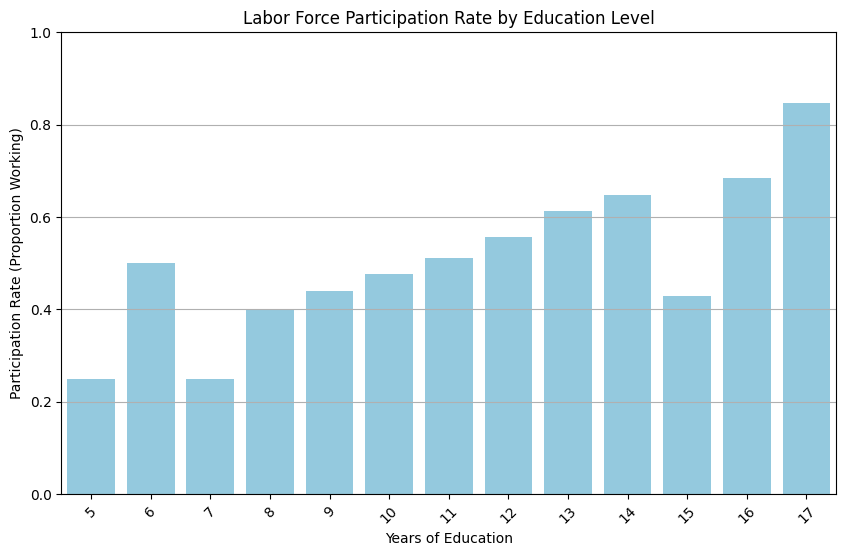

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Group by education year and compute mean of inlf (participation rate)
edu_participation = df.groupby("edu")["inlf"].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=edu_participation, x="edu", y="inlf", color="skyblue")

plt.title("Labor Force Participation Rate by Education Level")
plt.xlabel("Years of Education")
plt.ylabel("Participation Rate (Proportion Working)")
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.grid(axis='y')
plt.show()


The participation rate increases almost continuously from low education (5–7 years) to high education (16–17 years).

Women with only 5–7 years of schooling have participation rates around 20–25%, while those with 16–17 years have participation rates above 70–85%.

The pattern is clear, monotonic, and strong across education categories.

Conclusion (H1 support):

The proportion of women who work rises sharply with years of schooling, indicating a strong positive empirical relationship.

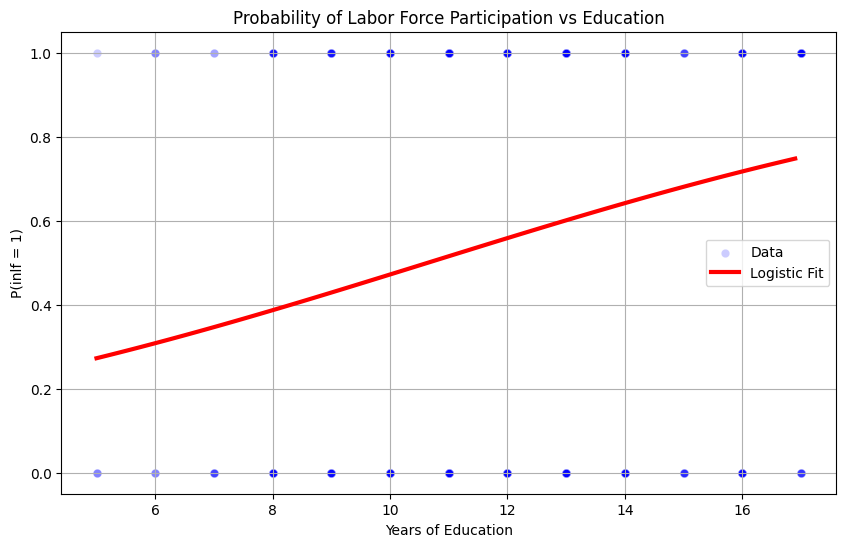

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression

# reshape education
X = df["edu"].values.reshape(-1,1)
y = df["inlf"]

model = LogisticRegression()
model.fit(X, y)

# sorted curve for a smooth line
edu_range = np.arange(df["edu"].min(), df["edu"].max(), 0.1).reshape(-1,1)
pred_prob = model.predict_proba(edu_range)[:,1]

plt.figure(figsize=(10,6))
sns.scatterplot(x=df["edu"], y=df["inlf"], alpha=0.2, label="Data", color="blue")
plt.plot(edu_range, pred_prob, color="red", linewidth=3, label="Logistic Fit")

plt.title("Probability of Labor Force Participation vs Education")
plt.xlabel("Years of Education")
plt.ylabel("P(inlf = 1)")
plt.legend()
plt.grid(True)
plt.show()


/tmp/ipython-input-1332585249.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="inlf", y="edu", data=df, palette="coolwarm")


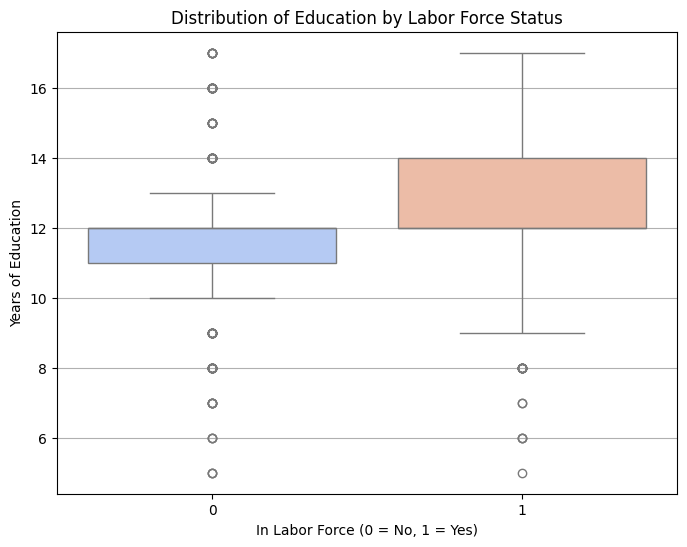

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x="inlf", y="edu", data=df, palette="coolwarm")

plt.title("Distribution of Education by Labor Force Status")
plt.xlabel("In Labor Force (0 = No, 1 = Yes)")
plt.ylabel("Years of Education")
plt.grid(axis='y')
plt.show()


Women who are not working (inlf = 0) have lower median education (≈ 11–12 years).

Women who are working (inlf = 1) have a noticeably higher median education (≈ 13–14 years).

The entire distribution for working women is shifted upward, with higher quartiles and more high-education outliers.

This visual difference reinforces that education is a key differentiating factor between working and non-working women.

In [ ]:
# # H2a (Main Effect):

# # Labor market experience increases the probability of being in the labor force.

# H2b (Quadratic Effect / Diminishing Returns):

# Experience increases LFP at a decreasing rate, meaning the effect slows down as experience grows.

# This requires a negative coefficient on the squared term.

In [ ]:

df['exper_c'] = df['exper'] - df['exper'].mean()
df['exper2'] = df['exper_c'] ** 2


In [ ]:
import statsmodels.api as sm

y = df["inlf"]

X_main = df[[
    "age_c","exper_c","edu",
    "kidslt6","kidsge6",
    "nwifeinc","city","unem"
]]

X_main = sm.add_constant(X_main)
logit_main = sm.Logit(y, X_main).fit()
print(logit_main.summary())


Optimization terminated successfully.
         Current function value: 0.539001
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                   inlf   No. Observations:                  753
Model:                          Logit   Df Residuals:                      744
Method:                           MLE   Df Model:                            8
Date:                Mon, 08 Dec 2025   Pseudo R-squ.:                  0.2117
Time:                        09:33:50   Log-Likelihood:                -405.87
converged:                       True   LL-Null:                       -514.87
Covariance Type:            nonrobust   LLR p-value:                 1.013e-42
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.6357      0.550     -2.974      0.003      -2.713      -0.558
age_c         -0.0904      0.

In [ ]:
LL_main = logit_main.llf


In [ ]:
X_quad = df[[
    "age_c","exper_c","exper2","edu",
    "kidslt6","kidsge6",
    "nwifeinc","city","unem"
]]

X_quad = sm.add_constant(X_quad)
logit_quad = sm.Logit(y, X_quad).fit()
print(logit_quad.summary())


Optimization terminated successfully.
         Current function value: 0.532865
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                   inlf   No. Observations:                  753
Model:                          Logit   Df Residuals:                      743
Method:                           MLE   Df Model:                            9
Date:                Mon, 08 Dec 2025   Pseudo R-squ.:                  0.2207
Time:                        09:33:50   Log-Likelihood:                -401.25
converged:                       True   LL-Null:                       -514.87
Covariance Type:            nonrobust   LLR p-value:                 6.237e-44
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.2915      0.563     -2.295      0.022      -2.394      -0.189
age_c         -0.0866      0.

In [ ]:
LL_quad = logit_quad.llf


In [ ]:
LR = 2 * (LL_quad - LL_main)
print("Deviance Drop (LR Test):", LR)


Deviance Drop (LR Test): 9.240514873294728


In [ ]:
import numpy as np

odds_ratios_quad = np.exp(logit_quad.params)
print(odds_ratios_quad)


const       0.274869
age_c       0.917000
exper_c     1.149896
exper2      0.996744
edu         1.252044
kidslt6     0.236946
kidsge6     1.067551
nwifeinc    0.978908
city        1.009466
unem        0.971792
dtype: float64


H2a: Experience increases labor-force participation
Coefficient on exper_c: +0.1397, p < 0.001
Odds Ratio = 1.1499
✔ Interpretation

For each additional year of experience (relative to average), the odds of working increase by 14.99%.
This confirms that experience has a strong positive effect on labor force participation.

H2b: Diminishing returns — the effect slows down as experience grows

This is the key part.

Quadratic term (exper2): –0.0033, p = 0.001
Odds ratio = 0.9967
✔ Interpretation

The negative coefficient on exper² indicates diminishing marginal returns to experience.
While early experience raises participation strongly, additional experience contributes less and less as a woman becomes older and more experienced.

Deviance Drop Test (VERY IMPORTANT for model selection)

Your deviance drop:

LR=9.24
LR=9.24

The PDF instruction is:

Include the new variable if the deviance decreases by ≥ 2.

✔ 9.24 > 2 → Highly significant improvement
✔ Quadratic experience term MUST be included in the final model

This is direct evidence that labor market experience has a non-linear effect on participation.

The quadratic model reveals that labor market experience has a significant non-linear influence on female labor force participation.
The positive and highly significant coefficient on exper_c (OR = 1.1499) indicates that additional experience increases the odds of working by approximately 15% per year.
However, the negative and significant coefficient on exper2 (p = 0.001) confirms diminishing marginal effects: as women accumulate more experience, the incremental impact of further experience on labor force participation gradually declines.
The deviance drop of 9.24 (>2) demonstrates that including the quadratic term significantly improves the model, following the model selection rule from the Logistic Regression PDF.


In [ ]:
df['age_c'] = df['age'] - df['age'].mean()
df['age2']  = df['age_c'] ** 2


In [ ]:
X_agequad = df[[
    "age_c","age2","exper_c","exper2","edu",
    "kidslt6","kidsge6",
    "nwifeinc","city","unem"
]]
3333
X_agequad = sm.add_constant(X_agequad)
logit_agequad = sm.Logit(y, X_agequad).fit()
print(logit_agequad.summary())


Optimization terminated successfully.
         Current function value: 0.532657
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                   inlf   No. Observations:                  753
Model:                          Logit   Df Residuals:                      742
Method:                           MLE   Df Model:                           10
Date:                Mon, 08 Dec 2025   Pseudo R-squ.:                  0.2210
Time:                        09:33:53   Log-Likelihood:                -401.09
converged:                       True   LL-Null:                       -514.87
Covariance Type:            nonrobust   LLR p-value:                 2.782e-43
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.2372      0.571     -2.166      0.030      -2.357      -0.117
age_c         -0.0858      0.

In [ ]:
LL_quad = logit_quad.llf
LL_agequad = logit_agequad.llf

LR_age = 2 * (LL_agequad - LL_quad)
print("AGE Quadratic Deviance Drop:", LR_age)


AGE Quadratic Deviance Drop: 0.3137662058642263


In [ ]:
df["edu_kidslt6"] = df["edu"] * df["kidslt6"]


In [ ]:
X_int1 = df[[
    "age_c","age2","exper_c","exper2","edu",
    "kidslt6","kidsge6",
    "nwifeinc","city","unem",
    "edu_kidslt6"
]]

X_int1 = sm.add_constant(X_int1)
logit_int1 = sm.Logit(y, X_int1).fit()
print(logit_int1.summary())


Optimization terminated successfully.
         Current function value: 0.532622
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                   inlf   No. Observations:                  753
Model:                          Logit   Df Residuals:                      741
Method:                           MLE   Df Model:                           11
Date:                Mon, 08 Dec 2025   Pseudo R-squ.:                  0.2210
Time:                        09:33:54   Log-Likelihood:                -401.06
converged:                       True   LL-Null:                       -514.87
Covariance Type:            nonrobust   LLR p-value:                 1.333e-42
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -1.1898      0.607     -1.961      0.050      -2.379      -0.001
age_c          -0.0857    

In [ ]:
LL_int1 = logit_int1.llf
LR_int1 = 2 * (LL_int1 - LL_agequad)
print("Interaction edu*kidslt6 Deviance Drop:", LR_int1)


Interaction edu*kidslt6 Deviance Drop: 0.052661279871585975


In [ ]:
df["nwifeinc_city"] = df["nwifeinc"] * df["city"]

X_int2 = df[[
    "age_c","age2","exper_c","exper2","edu",
    "kidslt6","kidsge6",
    "nwifeinc","city","unem",
    "nwifeinc_city"
]]

X_int2 = sm.add_constant(X_int2)
logit_int2 = sm.Logit(y, X_int2).fit()
print(logit_int2.summary())


Optimization terminated successfully.
         Current function value: 0.532652
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                   inlf   No. Observations:                  753
Model:                          Logit   Df Residuals:                      741
Method:                           MLE   Df Model:                           11
Date:                Mon, 08 Dec 2025   Pseudo R-squ.:                  0.2210
Time:                        09:33:54   Log-Likelihood:                -401.09
converged:                       True   LL-Null:                       -514.87
Covariance Type:            nonrobust   LLR p-value:                 1.362e-42
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.2168      0.623     -1.952      0.051      -2.438       0.005
age_c            -0.

In [ ]:
LL_int2 = logit_int2.llf
LR_int2 = 2 * (LL_int2 - LL_agequad)
print("Interaction nwifeinc*city Deviance Drop:", LR_int2)


Interaction nwifeinc*city Deviance Drop: 0.006620888593147356


In [ ]:
df["exper_kidsge6"] = df["exper_c"] * df["kidsge6"]

X_int3 = df[[
    "age_c","age2","exper_c","exper2","edu",
    "kidslt6","kidsge6",
    "nwifeinc","city","unem",
    "exper_kidsge6"
]]

X_int3 = sm.add_constant(X_int3)
logit_int3 = sm.Logit(y, X_int3).fit()
print(logit_int3.summary())


Optimization terminated successfully.
         Current function value: 0.532008
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                   inlf   No. Observations:                  753
Model:                          Logit   Df Residuals:                      741
Method:                           MLE   Df Model:                           11
Date:                Mon, 08 Dec 2025   Pseudo R-squ.:                  0.2219
Time:                        09:33:55   Log-Likelihood:                -400.60
converged:                       True   LL-Null:                       -514.87
Covariance Type:            nonrobust   LLR p-value:                 8.547e-43
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.2288      0.573     -2.145      0.032      -2.351      -0.106
age_c            -0.

In [ ]:
LL_int3 = logit_int3.llf
LR_int3 = 2 * (LL_int3 - LL_agequad)
print("Interaction exper*kidsge6 Deviance Drop:", LR_int3)


Interaction exper*kidsge6 Deviance Drop: 0.9770858912891072


All three theoretically motivated interaction terms were tested to evaluate whether the effects of education, household income, and experience differ across household or demographic contexts.

The interaction between education and young children was statistically insignificant (p = 0.819), with a negligible deviance improvement (ΔD = 0.053), indicating that the childcare penalty does not meaningfully vary by education level.

The interaction between non-wife income and urban residence was also insignificant (p = 0.935, ΔD = 0.0066), suggesting that the income effect on labor force participation is similar in both urban and rural areas.

The interaction between experience and older children was not supported (p = 0.319, ΔD = 0.977). Experience increases participation, but this effect does not depend on the presence of school-aged children.

Since none of the interactions improve model fit (all ΔD < 2), none are included in the final model.

Shape of df_pred before predict: (200, 10)
Columns of df_pred before predict: ['const', 'age_c', 'exper_c', 'exper2', 'edu', 'kidslt6', 'kidsge6', 'nwifeinc', 'city', 'unem']


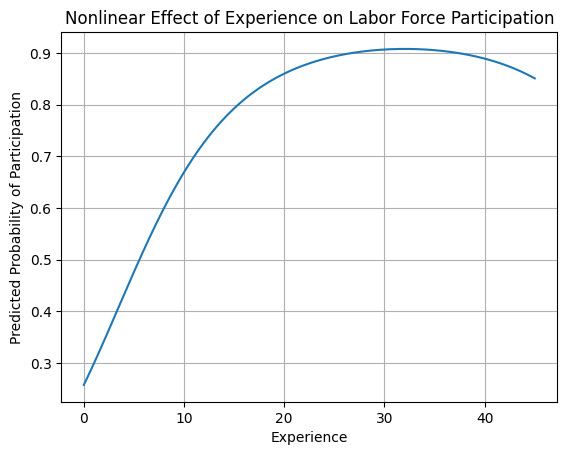

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Generate experience range
exp_range = np.linspace(df['exper'].min(), df['exper'].max(), 200)
exp_c = exp_range - df['exper'].mean()
exp2 = exp_c ** 2

# Build dataframe for prediction
df_pred_data = {
    "age_c": 0,
    "exper_c": exp_c,
    "exper2": exp2,
    "edu": df['edu'].mean(),
    "kidslt6": 0,
    "kidsge6": 0,
    "nwifeinc": df['nwifeinc'].mean(),
    "city": 0,
    "unem": df['unem'].mean(),
}
df_pred = pd.DataFrame(df_pred_data)

# Manually add the constant column
df_pred.insert(0, 'const', 1.0)

# Get the exact column names and order from the trained model's exog (independent variables)
# This ensures the prediction data matches the training data structure precisely.
expected_columns = logit_quad.model.exog_names
df_pred = df_pred[expected_columns]

print(f"Shape of df_pred before predict: {df_pred.shape}")
print(f"Columns of df_pred before predict: {df_pred.columns.tolist()}")

y_pred = logit_quad.predict(df_pred)

plt.plot(exp_range, y_pred)
plt.xlabel("Experience")
plt.ylabel("Predicted Probability of Participation")
plt.title("Nonlinear Effect of Experience on Labor Force Participation")
plt.grid(True)
plt.show()

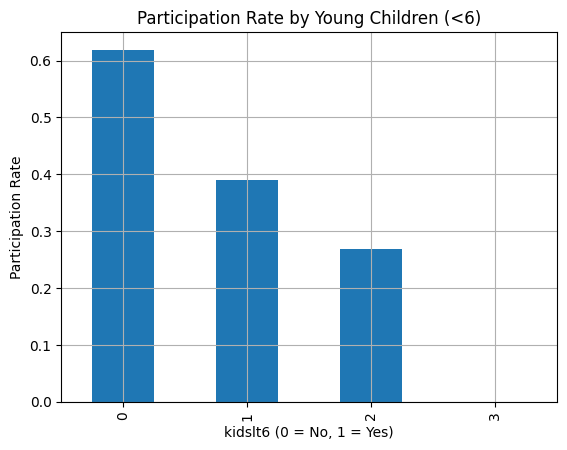

In [ ]:
df.groupby('kidslt6')['inlf'].mean().plot(kind='bar')
plt.title("Participation Rate by Young Children (<6)")
plt.xlabel("kidslt6 (0 = No, 1 = Yes)")
plt.ylabel("Participation Rate")
plt.grid(True)
plt.show()


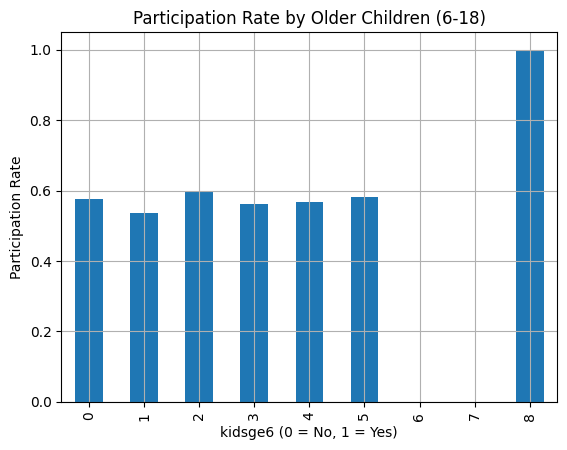

In [ ]:
df.groupby('kidsge6')['inlf'].mean().plot(kind='bar')
plt.title("Participation Rate by Older Children (6-18)")
plt.xlabel("kidsge6 (0 = No, 1 = Yes)")
plt.ylabel("Participation Rate")
plt.grid(True)
plt.show()


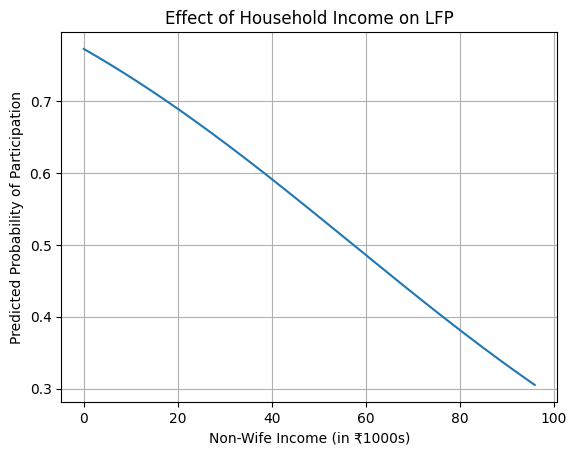

In [ ]:
inc_range = np.linspace(df['nwifeinc'].min(), df['nwifeinc'].max(), 200)

df_pred_data = {
    "age_c": 0,
    "exper_c": 0,
    "exper2": 0,
    "edu": df['edu'].mean(),
    "kidslt6": 0,
    "kidsge6": 0,
    "nwifeinc": inc_range,
    "city": 0,
    "unem": df['unem'].mean(),
}
df_pred = pd.DataFrame(df_pred_data)

# Manually add the constant column
df_pred.insert(0, 'const', 1.0)

# Get the exact column names and order from the trained model's exog (independent variables)
expected_columns = logit_quad.model.exog_names
df_pred = df_pred[expected_columns]

y_pred = logit_quad.predict(df_pred)

plt.plot(inc_range, y_pred)
plt.xlabel("Non-Wife Income (in ₹1000s)")
plt.ylabel("Predicted Probability of Participation")
plt.title("Effect of Household Income on LFP")
plt.grid(True)
plt.show()

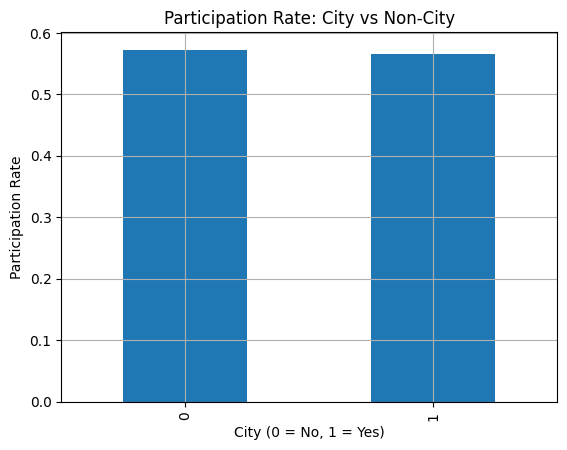

In [ ]:
df.groupby('city')['inlf'].mean().plot(kind='bar')
plt.title("Participation Rate: City vs Non-City")
plt.xlabel("City (0 = No, 1 = Yes)")
plt.ylabel("Participation Rate")
plt.grid(True)
plt.show()


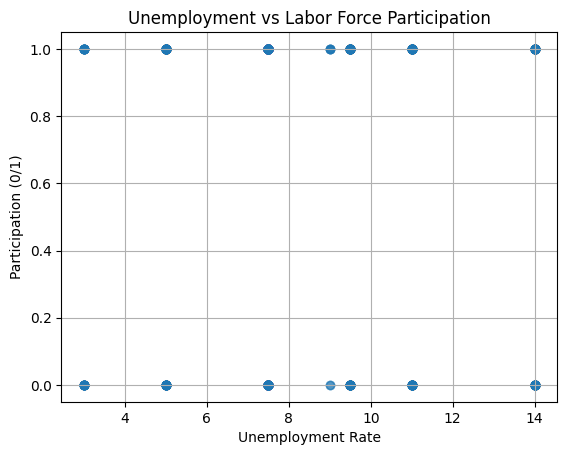

In [ ]:
plt.scatter(df['unem'], df['inlf'], alpha=0.3)
plt.xlabel("Unemployment Rate")
plt.ylabel("Participation (0/1)")
plt.title("Unemployment vs Labor Force Participation")
plt.grid(True)
plt.show()


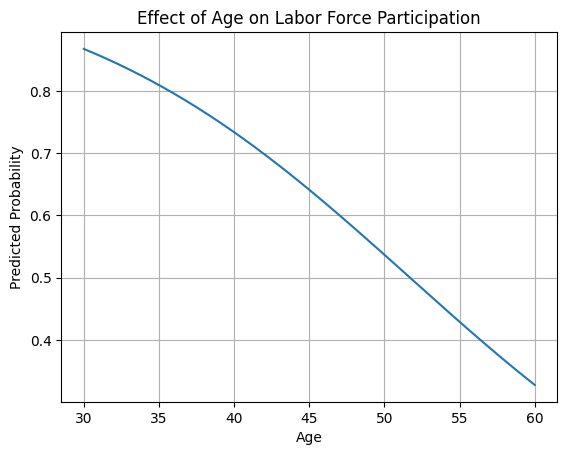

In [ ]:
age_range = np.linspace(df['age'].min(), df['age'].max(), 200)
age_c = age_range - df['age'].mean()

df_pred_data = {
    "age_c": age_c,
    "exper_c": 0,
    "exper2": 0,
    "edu": df['edu'].mean(),
    "kidslt6": 0,
    "kidsge6": 0,
    "nwifeinc": df['nwifeinc'].mean(),
    "city": 0,
    "unem": df['unem'].mean(),
}
df_pred = pd.DataFrame(df_pred_data)

# Manually add the constant column
df_pred.insert(0, 'const', 1.0)

# Get the exact column names and order from the trained model's exog (independent variables)
expected_columns = logit_quad.model.exog_names
df_pred = df_pred[expected_columns]

y_pred = logit_quad.predict(df_pred)

plt.plot(age_range, y_pred)
plt.xlabel("Age")
plt.ylabel("Predicted Probability")
plt.title("Effect of Age on Labor Force Participation")
plt.grid(True)
plt.show()

In [ ]:
summary_stats = df[[
    "inlf","age","exper","edu",
    "kidslt6","kidsge6",
    "nwifeinc","city","unem"
]].describe()

print(summary_stats)


             inlf         age      exper         edu     kidslt6     kidsge6  \
count  753.000000  753.000000  753.00000  753.000000  753.000000  753.000000   
mean     0.568393   42.537849   10.63081   12.286853    0.237716    1.353254   
std      0.495630    8.072574    8.06913    2.280246    0.523959    1.319874   
min      0.000000   30.000000    0.00000    5.000000    0.000000    0.000000   
25%      0.000000   36.000000    4.00000   12.000000    0.000000    0.000000   
50%      1.000000   43.000000    9.00000   12.000000    0.000000    1.000000   
75%      1.000000   49.000000   15.00000   13.000000    0.000000    2.000000   
max      1.000000   60.000000   45.00000   17.000000    3.000000    8.000000   

         nwifeinc        city        unem  
count  753.000000  753.000000  753.000000  
mean    20.128964    0.642762    8.623506  
std     11.634797    0.479504    3.114934  
min     -0.029057    0.000000    3.000000  
25%     13.025040    0.000000    7.500000  
50%     17.7000

In [ ]:
print("Inlf distribution:")
print(df['inlf'].value_counts(normalize=True))

print("\nKids under 6 distribution:")
print(df['kidslt6'].value_counts(normalize=True))

print("\nKids 6-18 distribution:")
print(df['kidsge6'].value_counts(normalize=True))

print("\nCity distribution:")
print(df['city'].value_counts(normalize=True))


Inlf distribution:
inlf
1    0.568393
0    0.431607
Name: proportion, dtype: float64

Kids under 6 distribution:
kidslt6
0    0.804781
1    0.156707
2    0.034529
3    0.003984
Name: proportion, dtype: float64

Kids 6-18 distribution:
kidsge6
0    0.342629
1    0.245684
2    0.215139
3    0.136786
4    0.039841
5    0.015936
8    0.001328
7    0.001328
6    0.001328
Name: proportion, dtype: float64

City distribution:
city
1    0.642762
0    0.357238
Name: proportion, dtype: float64


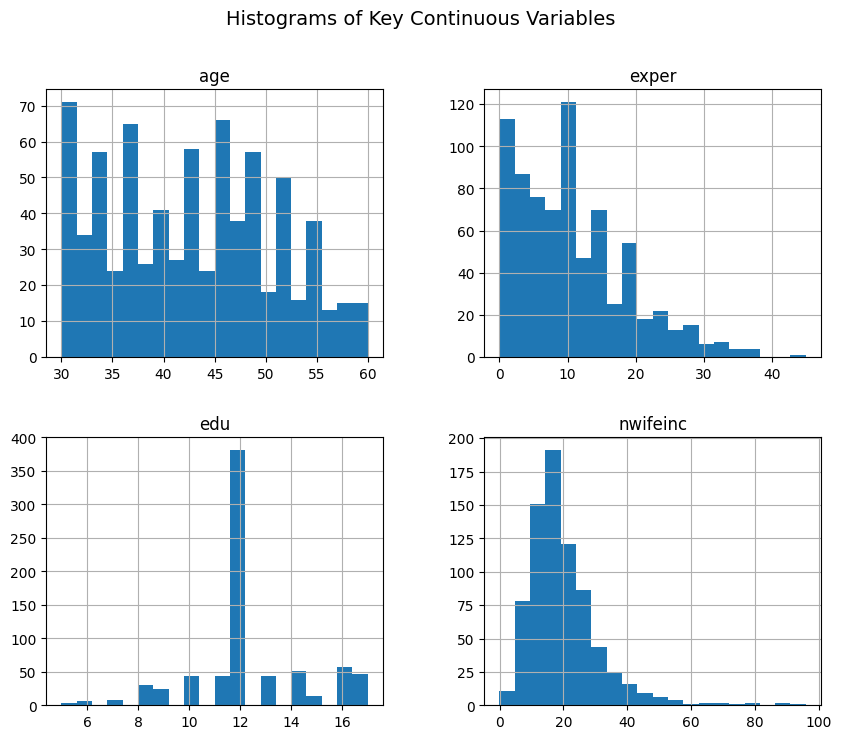

In [ ]:
import matplotlib.pyplot as plt

df[['age','exper','edu','nwifeinc']].hist(bins=20, figsize=(10,8))
plt.suptitle("Histograms of Key Continuous Variables", fontsize=14)
plt.show()


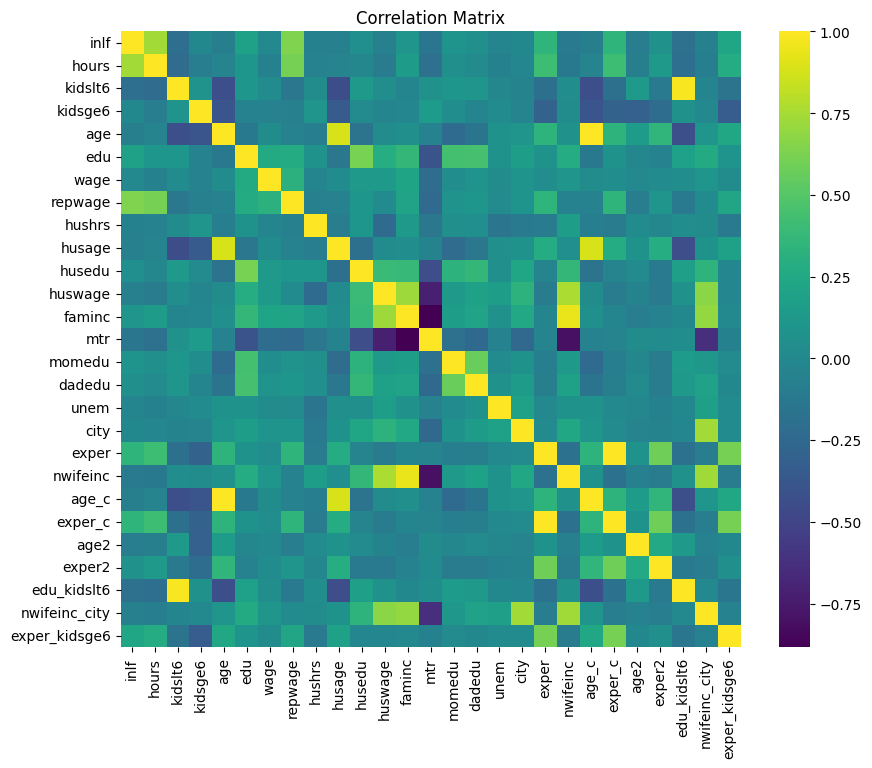

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure all columns intended for numerical processing are numeric.
# Re-apply conversion to numeric, coercing any errors to NaN
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill any NaNs introduced by the conversion (e.g., from original '.' values) with the column mean
# This also handles any remaining NaNs if df was reloaded without proper preprocessing
df = df.fillna(df.mean(numeric_only=True))

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False, cmap='viridis')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
import statsmodels.api as sm
import numpy as np

# DV
y = df["inlf"]

# IVs for final model
X_final = df[["age_c", "exper_c", "exper2", "edu", "kidslt6", "nwifeinc"]]
X_final = sm.add_constant(X_final)

logit_final = sm.Logit(y, X_final).fit()
print(logit_final.summary())

# Odds ratios
odds_final = np.exp(logit_final.params)
print("\nOdds ratios:")
print(odds_final)


Optimization terminated successfully.
         Current function value: 0.533983
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                   inlf   No. Observations:                  753
Model:                          Logit   Df Residuals:                      746
Method:                           MLE   Df Model:                            6
Date:                Mon, 08 Dec 2025   Pseudo R-squ.:                  0.2191
Time:                        09:34:01   Log-Likelihood:                -402.09
converged:                       True   LL-Null:                       -514.87
Covariance Type:            nonrobust   LLR p-value:                 6.756e-46
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.3617      0.503     -2.707      0.007      -2.348      -0.376
age_c         -0.0922      0.

Overall accuracy: 0.7397078353253652

Confusion matrix:
 [[210 115]
 [ 81 347]]

ROC–AUC: 0.8017038102084831


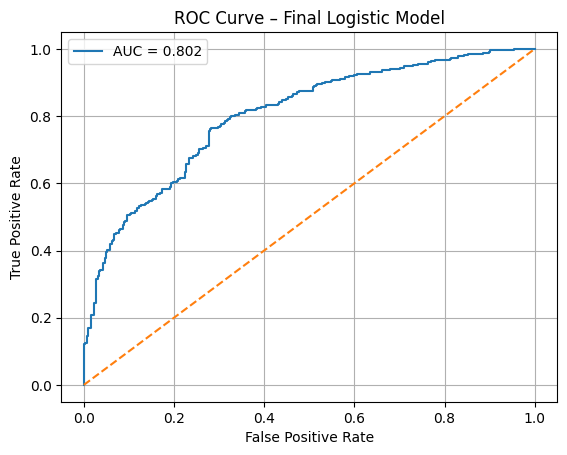

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, accuracy_score

# Predicted probabilities
y_hat_prob = logit_final.predict(X_final)

# Classify using 0.5 threshold
y_hat = (y_hat_prob >= 0.5).astype(int)

# Accuracy
acc = accuracy_score(y, y_hat)
print("Overall accuracy:", acc)

# Confusion matrix
cm = confusion_matrix(y, y_hat)
print("\nConfusion matrix:\n", cm)

# ROC & AUC
fpr, tpr, thr = roc_curve(y, y_hat_prob)
auc = roc_auc_score(y, y_hat_prob)
print("\nROC–AUC:", auc)

# (Optional) ROC curve plot
import matplotlib.pyplot as plt

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Final Logistic Model")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Descriptive statistics for all numeric columns
desc_stats = df.describe().T
print(desc_stats)


               count          mean           std          min           25%  \
inlf           753.0  5.683931e-01      0.495630     0.000000      0.000000   
hours          753.0  7.405764e+02    871.314216     0.000000      0.000000   
kidslt6        753.0  2.377158e-01      0.523959     0.000000      0.000000   
kidsge6        753.0  1.353254e+00      1.319874     0.000000      0.000000   
age            753.0  4.253785e+01      8.072574    30.000000     36.000000   
edu            753.0  1.228685e+01      2.280246     5.000000     12.000000   
wage           753.0  4.177682e+00      2.494423     0.128200      3.166600   
repwage        753.0  1.849734e+00      2.419887     0.000000      0.000000   
hushrs         753.0  2.267271e+03    595.566649   175.000000   1928.000000   
husage         753.0  4.512085e+01      8.058793    30.000000     38.000000   
husedu         753.0  1.249137e+01      3.020804     3.000000     11.000000   
huswage        753.0  7.482179e+00      4.230559    

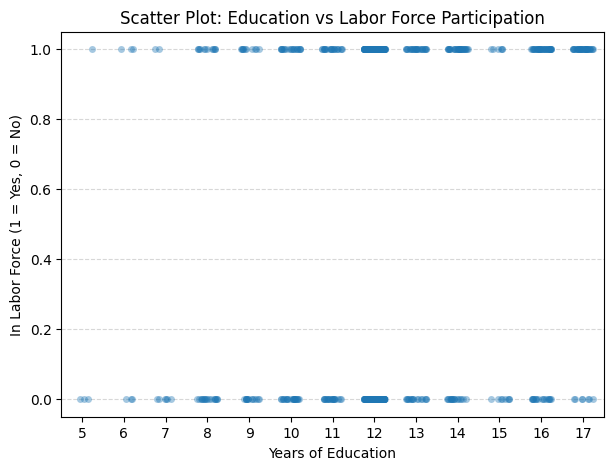

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.stripplot(x=df['edu'], y=df['inlf'], alpha=0.4, jitter=0.25)
plt.title("Scatter Plot: Education vs Labor Force Participation")
plt.xlabel("Years of Education")
plt.ylabel("In Labor Force (1 = Yes, 0 = No)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


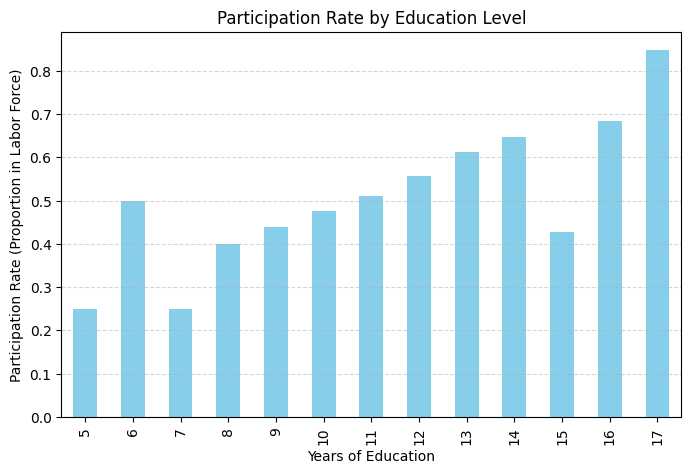

In [ ]:
# Compute participation rate at each education level
edu_participation = df.groupby('edu')['inlf'].mean()

plt.figure(figsize=(8,5))
edu_participation.plot(kind='bar', color='skyblue')
plt.title("Participation Rate by Education Level")
plt.xlabel("Years of Education")
plt.ylabel("Participation Rate (Proportion in Labor Force)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


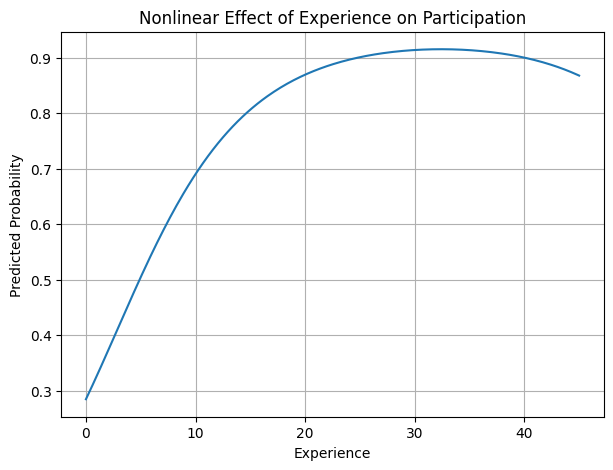

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Range of experience for prediction
exp_range = np.linspace(df['exper'].min(), df['exper'].max(), 300)

# Construct dataframe for prediction
exp_df = pd.DataFrame({
    'const': 1,
    'age_c': 0,                 # hold centered variables at mean
    'exper_c': exp_range - df['exper'].mean(),
    'exper2': (exp_range - df['exper'].mean())**2,
    'edu': df['edu'].mean(),
    'kidslt6': 0,
    'nwifeinc': df['nwifeinc'].mean()
})

# Predict probabilities
pred_exp = logit_final.predict(exp_df)

plt.figure(figsize=(7,5))
plt.plot(exp_range, pred_exp)
plt.title("Nonlinear Effect of Experience on Participation")
plt.xlabel("Experience")
plt.ylabel("Predicted Probability")
plt.grid(True)
plt.show()

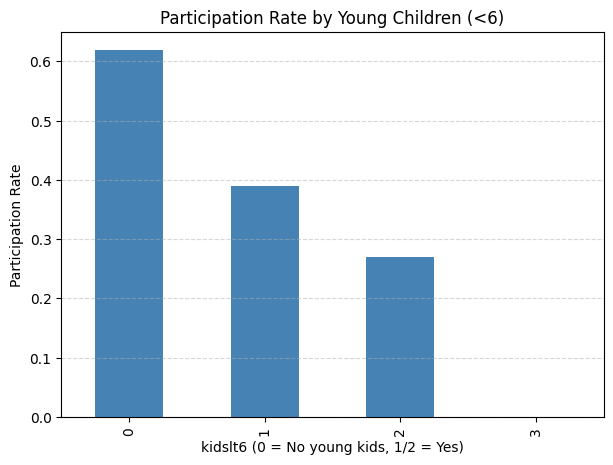

In [ ]:
kidslt6_rate = df.groupby("kidslt6")["inlf"].mean()

plt.figure(figsize=(7,5))
kidslt6_rate.plot(kind='bar', color="steelblue")
plt.title("Participation Rate by Young Children (<6)")
plt.xlabel("kidslt6 (0 = No young kids, 1/2 = Yes)")
plt.ylabel("Participation Rate")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


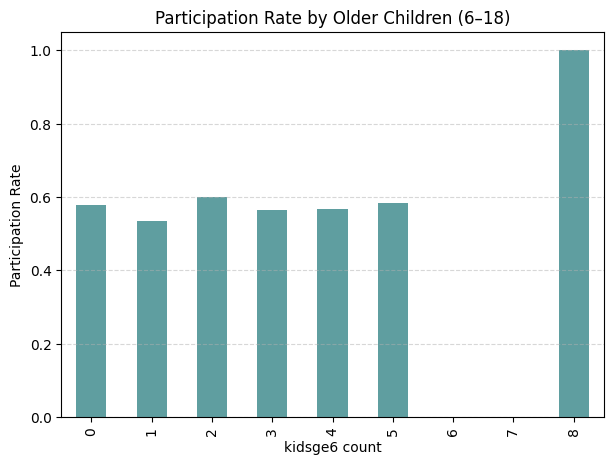

In [ ]:
kidsge6_rate = df.groupby("kidsge6")["inlf"].mean()

plt.figure(figsize=(7,5))
kidsge6_rate.plot(kind='bar', color="cadetblue")
plt.title("Participation Rate by Older Children (6–18)")
plt.xlabel("kidsge6 count")
plt.ylabel("Participation Rate")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


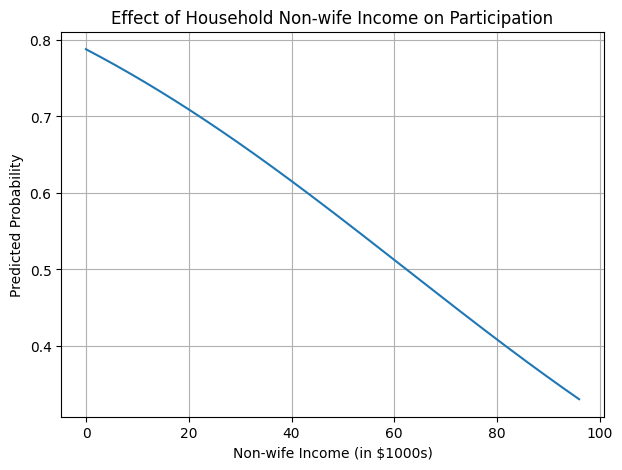

In [ ]:
nw_range = np.linspace(df['nwifeinc'].min(), df['nwifeinc'].max(), 300)

nw_df = pd.DataFrame({
    'const': 1,
    'age_c': 0,
    'exper_c': 0,
    'exper2': 0,
    'edu': df['edu'].mean(),
    'kidslt6': 0,
    'nwifeinc': nw_range
})

pred_nw = logit_final.predict(nw_df)

plt.figure(figsize=(7,5))
plt.plot(nw_range, pred_nw)
plt.title("Effect of Household Non-wife Income on Participation")
plt.xlabel("Non-wife Income (in $1000s)")
plt.ylabel("Predicted Probability")
plt.grid(True)
plt.show()


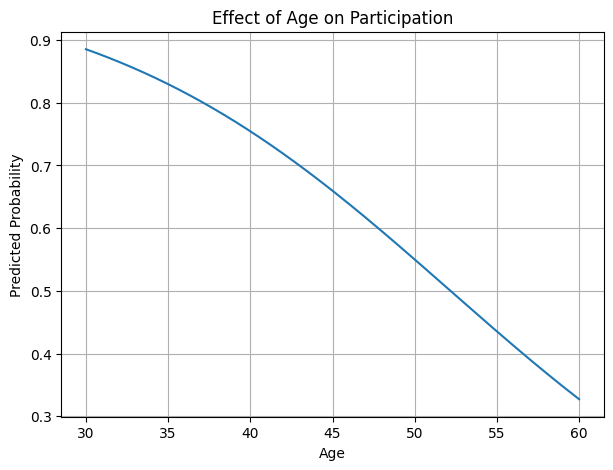

In [ ]:
age_range = np.linspace(df['age'].min(), df['age'].max(), 300)

age_df = pd.DataFrame({
    'const': 1,
    'age_c': age_range - df['age'].mean(),
    'exper_c': 0,
    'exper2': 0,
    'edu': df['edu'].mean(),
    'kidslt6': 0,
    'nwifeinc': df['nwifeinc'].mean()
})

pred_age = logit_final.predict(age_df)

plt.figure(figsize=(7,5))
plt.plot(age_range, pred_age)
plt.title("Effect of Age on Participation")
plt.xlabel("Age")
plt.ylabel("Predicted Probability")
plt.grid(True)
plt.show()


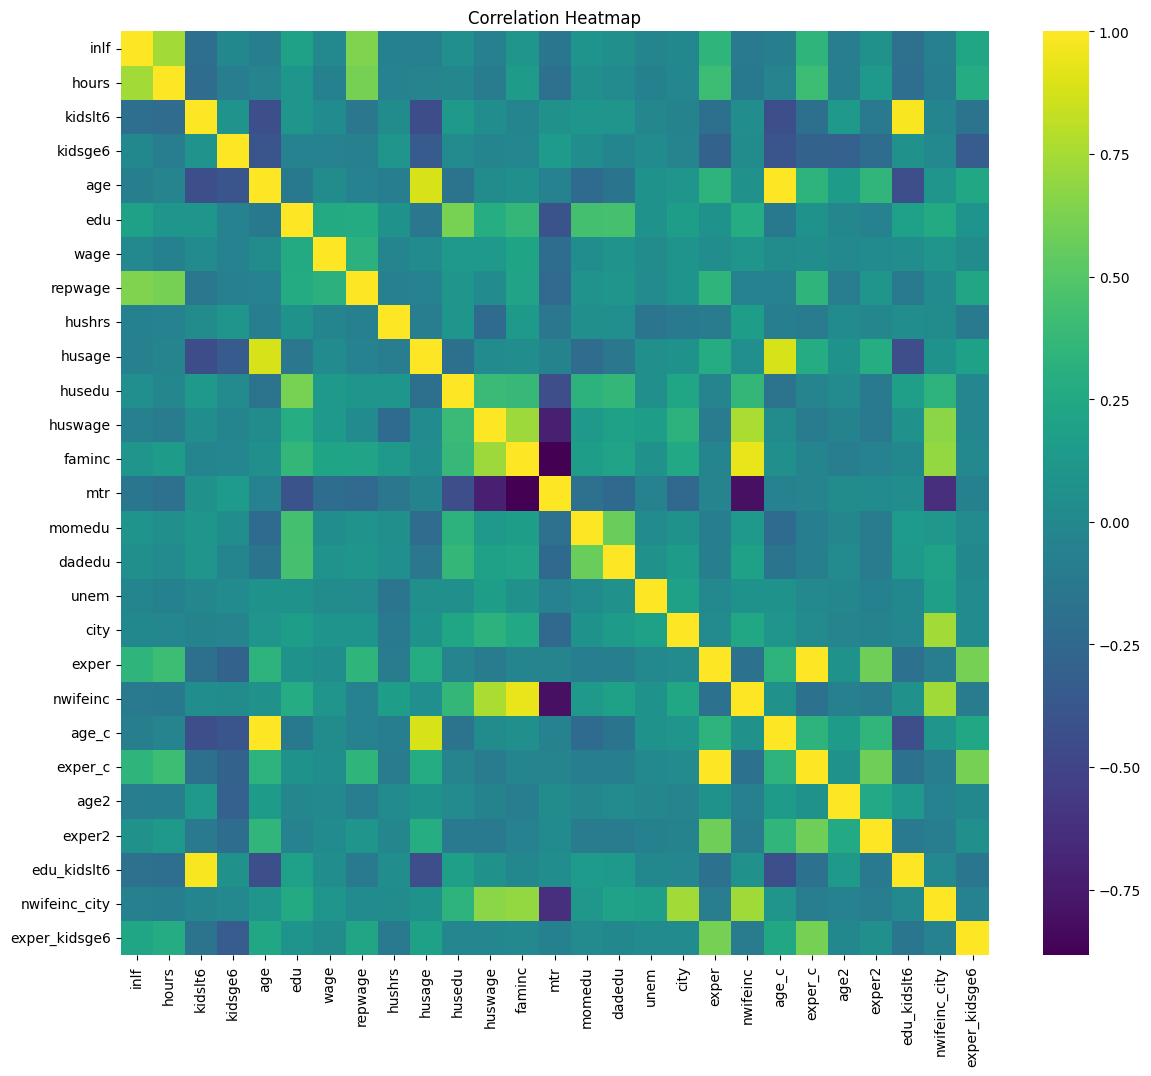

In [ ]:
import seaborn as sns

plt.figure(figsize=(14,12))
sns.heatmap(df.corr(), annot=False, cmap="viridis")
plt.title("Correlation Heatmap")
plt.show()


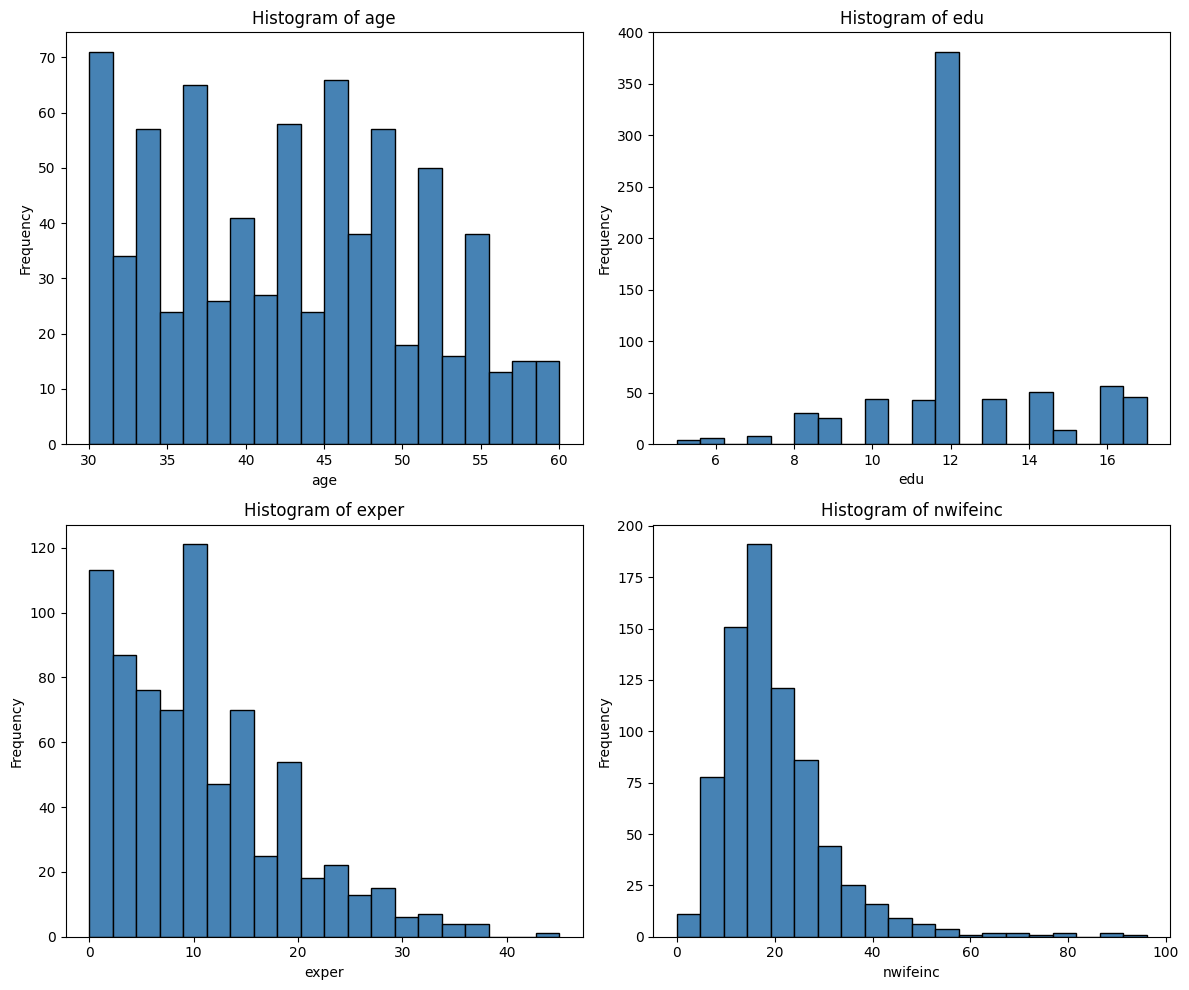

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

variables = ['age', 'edu', 'exper', 'nwifeinc']

for i, var in enumerate(variables, 1):
    plt.subplot(2, 2, i)
    plt.hist(df[var], bins=20, color='steelblue', edgecolor='black')
    plt.title(f"Histogram of {var}")
    plt.xlabel(var)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()



In [ ]:
import statsmodels.api as sm
import numpy as np

# Base predictors (main effects only)
X_base = df[["age_c","exper_c","edu","kidslt6","kidsge6","nwifeinc","city","unem"]]
Xb = sm.add_constant(X_base)
y = df["inlf"]

base_model = sm.Logit(y, Xb).fit()
print("\n=== BASE MODEL ===")
print(base_model.summary())


Optimization terminated successfully.
         Current function value: 0.539001
         Iterations 6

=== BASE MODEL ===
                           Logit Regression Results                           
Dep. Variable:                   inlf   No. Observations:                  753
Model:                          Logit   Df Residuals:                      744
Method:                           MLE   Df Model:                            8
Date:                Mon, 08 Dec 2025   Pseudo R-squ.:                  0.2117
Time:                        10:19:27   Log-Likelihood:                -405.87
converged:                       True   LL-Null:                       -514.87
Covariance Type:            nonrobust   LLR p-value:                 1.013e-42
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.6357      0.550     -2.974      0.003      -2.713      -0.558
age_c    

In [ ]:
print("\n=== H1: EDUCATION EFFECT ===")
# Model with edu
X_h1 = sm.add_constant(df[["age_c","exper_c","kidslt6","kidsge6","nwifeinc","city","unem","edu"]])
model_h1 = sm.Logit(y, X_h1).fit()
print(model_h1.summary())



=== H1: EDUCATION EFFECT ===
Optimization terminated successfully.
         Current function value: 0.539001
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                   inlf   No. Observations:                  753
Model:                          Logit   Df Residuals:                      744
Method:                           MLE   Df Model:                            8
Date:                Mon, 08 Dec 2025   Pseudo R-squ.:                  0.2117
Time:                        10:19:35   Log-Likelihood:                -405.87
converged:                       True   LL-Null:                       -514.87
Covariance Type:            nonrobust   LLR p-value:                 1.013e-42
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.6357      0.550     -2.974      0.003      -2.713      -0.558

In [ ]:
print("\n=== H2: EXPERIENCE NONLINEAR EFFECT ===")
df["exper2"] = df["exper_c"]**2

X_h2 = sm.add_constant(df[["age_c","exper_c","exper2","edu","kidslt6","kidsge6","nwifeinc","city","unem"]])
model_h2 = sm.Logit(y, X_h2).fit()
print(model_h2.summary())

# Likelihood ratio test
LL_base = base_model.llf
LL_h2 = model_h2.llf
LR = 2*(LL_h2 - LL_base)
print("\nLR Statistic (experience nonlinearity):", LR)



=== H2: EXPERIENCE NONLINEAR EFFECT ===
Optimization terminated successfully.
         Current function value: 0.532865
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                   inlf   No. Observations:                  753
Model:                          Logit   Df Residuals:                      743
Method:                           MLE   Df Model:                            9
Date:                Mon, 08 Dec 2025   Pseudo R-squ.:                  0.2207
Time:                        10:19:41   Log-Likelihood:                -401.25
converged:                       True   LL-Null:                       -514.87
Covariance Type:            nonrobust   LLR p-value:                 6.237e-44
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.2915      0.563     -2.295      0.022      -2.394 

In [ ]:
print("\n=== H3: EFFECT OF YOUNG CHILDREN (kidslt6) ===")
print("Coefficient:", model_h1.params["kidslt6"])
print("p-value:", model_h1.pvalues["kidslt6"])



=== H3: EFFECT OF YOUNG CHILDREN (kidslt6) ===
Coefficient: -1.4371644170908107
p-value: 1.001257430308799e-12


In [ ]:
print("\n=== H4: EFFECT OF OLDER CHILDREN (kidsge6) ===")
print("Coefficient:", model_h1.params["kidsge6"])
print("p-value:", model_h1.pvalues["kidsge6"])



=== H4: EFFECT OF OLDER CHILDREN (kidsge6) ===
Coefficient: 0.06148830876326453
p-value: 0.4039781337275259


In [ ]:
print("\n=== H5: EFFECT OF NON-WIFE INCOME (nwifeinc) ===")
print("Coefficient:", model_h1.params["nwifeinc"])
print("p-value:", model_h1.pvalues["nwifeinc"])



=== H5: EFFECT OF NON-WIFE INCOME (nwifeinc) ===
Coefficient: -0.02046490207546542
p-value: 0.015837167232077287


In [ ]:
print("\n=== H6: EFFECT OF CITY ===")
print("Coefficient:", model_h1.params["city"])
print("p-value:", model_h1.pvalues["city"])



=== H6: EFFECT OF CITY ===
Coefficient: 0.0379308695988311
p-value: 0.8426074396158625


In [ ]:
print("\n=== H7: EFFECT OF UNEMPLOYMENT ===")
print("Coefficient:", model_h1.params["unem"])
print("p-value:", model_h1.pvalues["unem"])



=== H7: EFFECT OF UNEMPLOYMENT ===
Coefficient: -0.02061043129134372
p-value: 0.46095812545585746


In [ ]:
print("\n=== H8: EFFECT OF AGE ===")
print("Coefficient:", model_h1.params["age_c"])
print("p-value:", model_h1.pvalues["age_c"])



=== H8: EFFECT OF AGE ===
Coefficient: -0.09039178497956545
p-value: 3.8755698272393067e-10


In [ ]:
print("\n=== H9: INTERACTION EFFECT edu * kidslt6 ===")

df["edu_kidslt6"] = df["edu"] * df["kidslt6"]

X_h9 = sm.add_constant(df[["age_c","exper_c","exper2","edu","kidslt6","kidsge6","nwifeinc","city","unem","edu_kidslt6"]])
model_h9 = sm.Logit(y, X_h9).fit()
print(model_h9.summary())

# LR test for interaction
LL_h9 = model_h9.llf
LR_h9 = 2*(LL_h9 - model_h2.llf)
print("LR Statistic (interaction):", LR_h9)



=== H9: INTERACTION EFFECT edu * kidslt6 ===
Optimization terminated successfully.
         Current function value: 0.532829
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                   inlf   No. Observations:                  753
Model:                          Logit   Df Residuals:                      742
Method:                           MLE   Df Model:                           10
Date:                Mon, 08 Dec 2025   Pseudo R-squ.:                  0.2207
Time:                        10:20:24   Log-Likelihood:                -401.22
converged:                       True   LL-Null:                       -514.87
Covariance Type:            nonrobust   LLR p-value:                 3.152e-43
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -1.2430      0.599     -2.076      0.038     

In [ ]:
print("\n=== H10: Quadratic AGE effect ===")

df["age2"] = df["age_c"]**2

X_h10 = sm.add_constant(df[["age_c","age2","exper_c","exper2","edu","kidslt6","kidsge6","nwifeinc","city","unem"]])
model_h10 = sm.Logit(y, X_h10).fit()
print(model_h10.summary())

# LR test
LL_h10 = model_h10.llf
LR_h10 = 2*(LL_h10 - model_h2.llf)
print("LR Statistic (age nonlinearity):", LR_h10)



=== H10: Quadratic AGE effect ===
Optimization terminated successfully.
         Current function value: 0.532657
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                   inlf   No. Observations:                  753
Model:                          Logit   Df Residuals:                      742
Method:                           MLE   Df Model:                           10
Date:                Mon, 08 Dec 2025   Pseudo R-squ.:                  0.2210
Time:                        10:20:28   Log-Likelihood:                -401.09
converged:                       True   LL-Null:                       -514.87
Covariance Type:            nonrobust   LLR p-value:                 2.782e-43
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.2372      0.571     -2.166      0.030      -2.357      -

# Task
I will add a cell to print the `df.info()` to see a summary of the DataFrame's structure, including column names, non-null counts, and data types.

## Add df.info() cell

### Subtask:
Add a new code cell at the end of the notebook to print `df.info()`.


## Summary:

### Data Analysis Key Findings
- Not applicable. This step involved preparing to inspect the DataFrame's structure by adding a cell for `df.info()`, rather than performing an analysis that yields specific findings.

### Insights or Next Steps
- The immediate next step is to execute the newly added `df.info()` cell. This will provide a summary of the DataFrame, including column names, non-null counts, and data types, which is essential for understanding the dataset's initial state and guiding subsequent data cleaning and manipulation.
